<a href="https://colab.research.google.com/github/akshayjha5639/Ferry-Forecast/blob/master/Ferry_tickets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [11]:
df=pd.read_csv('/content/Toronto Island Ferry Tickets.csv')
df=df.drop(['_id'],axis=1)
df.head()

,Timestamp,Redemption Count,Sales Count
0,2025-12-21T22:30:00,14,16
1,2025-12-21T22:15:00,1,0
2,2025-12-21T22:00:00,2,0
3,2025-12-21T21:30:00,11,1
4,2025-12-21T21:15:00,10,0


In [12]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.head()

,Timestamp,Redemption Count,Sales Count
0,2025-12-21 22:30:00,14,16
1,2025-12-21 22:15:00,1,0
2,2025-12-21 22:00:00,2,0
3,2025-12-21 21:30:00,11,1
4,2025-12-21 21:15:00,10,0


In [13]:
df.columns = ['timestamp', 'redemptions', 'sales']
df = df.sort_values('timestamp').reset_index(drop=True)


In [14]:
df.head()

,timestamp,redemptions,sales
0,2015-05-01 13:30:00,0,1
1,2015-05-01 15:15:00,0,2
2,2015-05-01 15:45:00,0,1
3,2015-05-01 16:00:00,1,0
4,2015-05-04 16:00:00,0,2


In [15]:
print(df[['sales','redemptions']].head())

   sales  redemptions
0      1            0
1      2            0
2      1            0
3      0            1
4      2            0


In [16]:
full_range = pd.date_range(
    start=df['timestamp'].min(),
    end=df['timestamp'].max(),
    freq='15min'
)

missing = full_range.difference(df['timestamp'])
print(f"Expected intervals : {len(full_range)}")
print(f"Actual intervals   : {len(df)}")
print(f"Missing intervals  : {len(missing)}")


Expected intervals : 373189
Actual intervals   : 261538
Missing intervals  : 111651


In [17]:
full_range

DatetimeIndex(['2015-05-01 13:30:00', '2015-05-01 13:45:00',
               '2015-05-01 14:00:00', '2015-05-01 14:15:00',
               '2015-05-01 14:30:00', '2015-05-01 14:45:00',
               '2015-05-01 15:00:00', '2015-05-01 15:15:00',
               '2015-05-01 15:30:00', '2015-05-01 15:45:00',
               ...
               '2025-12-21 20:15:00', '2025-12-21 20:30:00',
               '2025-12-21 20:45:00', '2025-12-21 21:00:00',
               '2025-12-21 21:15:00', '2025-12-21 21:30:00',
               '2025-12-21 21:45:00', '2025-12-21 22:00:00',
               '2025-12-21 22:15:00', '2025-12-21 22:30:00'],
              dtype='datetime64[ns]', length=373189, freq='15min')

In [18]:
print("Null values:\n", df.isnull().sum())
print("\nZero-value rows:")
print(f"  Sales = 0    : {(df['sales'] == 0).sum()} rows")
print(f"  Redemptions = 0: {(df['redemptions'] == 0).sum()} rows")
print("\nBasic statistics:")
df[['sales', 'redemptions']].describe().round(2)

Null values:
 timestamp      0
redemptions    0
sales          0
dtype: int64

Zero-value rows:
  Sales = 0    : 20548 rows
  Redemptions = 0: 27830 rows

Basic statistics:


,sales,redemptions
count,261538.00,261538.00
mean,49.60,48.89
std,99.86,104.55
min,0.00,0.00
25%,3.00,3.00
50%,13.00,11.00
75%,48.00,40.00
max,7229.00,7216.00


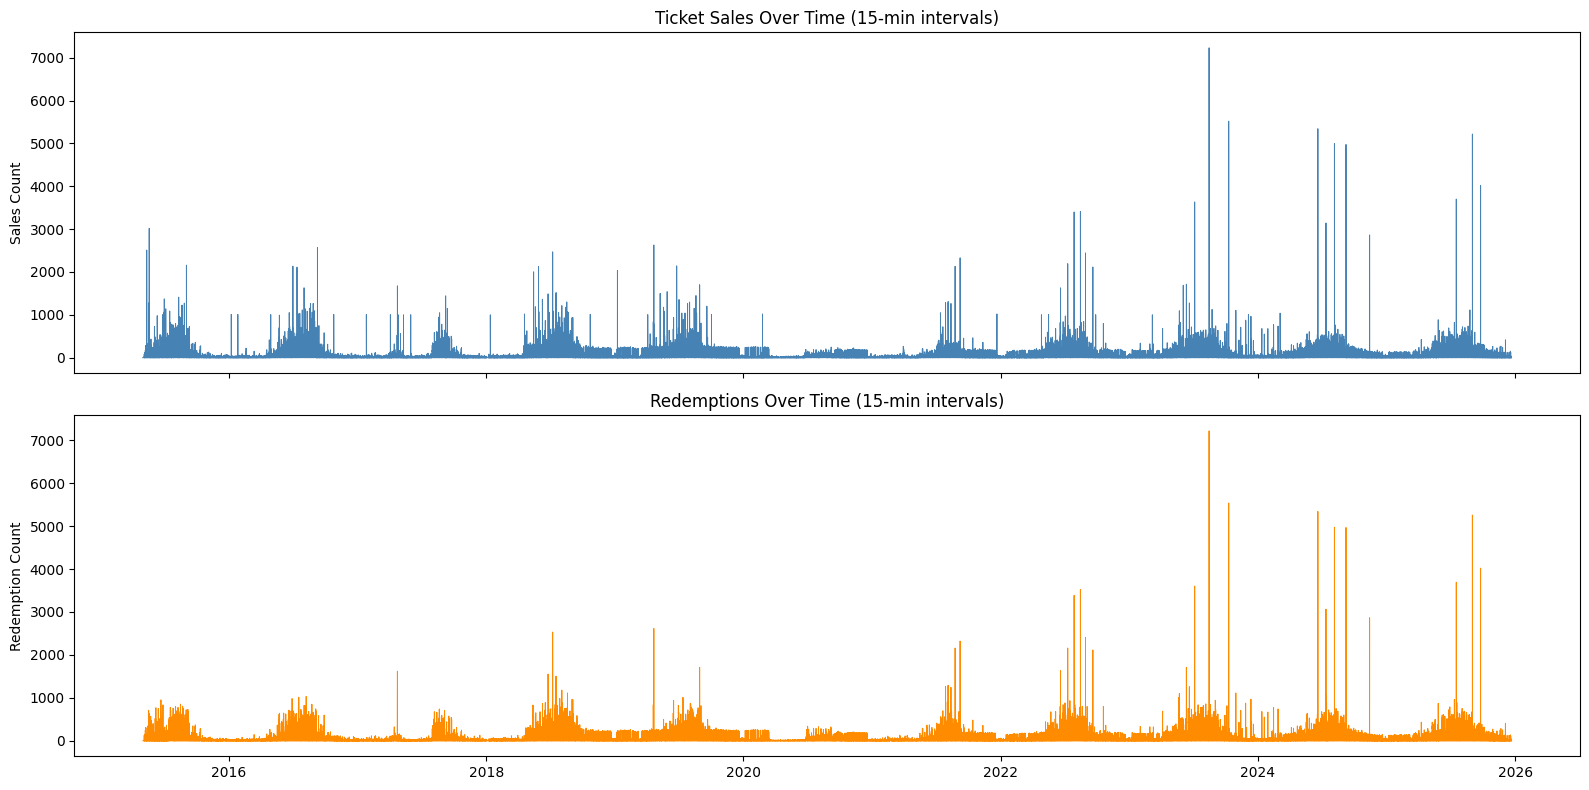

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df['timestamp'], df['sales'], color='steelblue', linewidth=0.7)
axes[0].set_title('Ticket Sales Over Time (15-min intervals)')
axes[0].set_ylabel('Sales Count')

axes[1].plot(df['timestamp'], df['redemptions'], color='darkorange', linewidth=0.7)
axes[1].set_title('Redemptions Over Time (15-min intervals)')
axes[1].set_ylabel('Redemption Count')

plt.tight_layout()
plt.show()

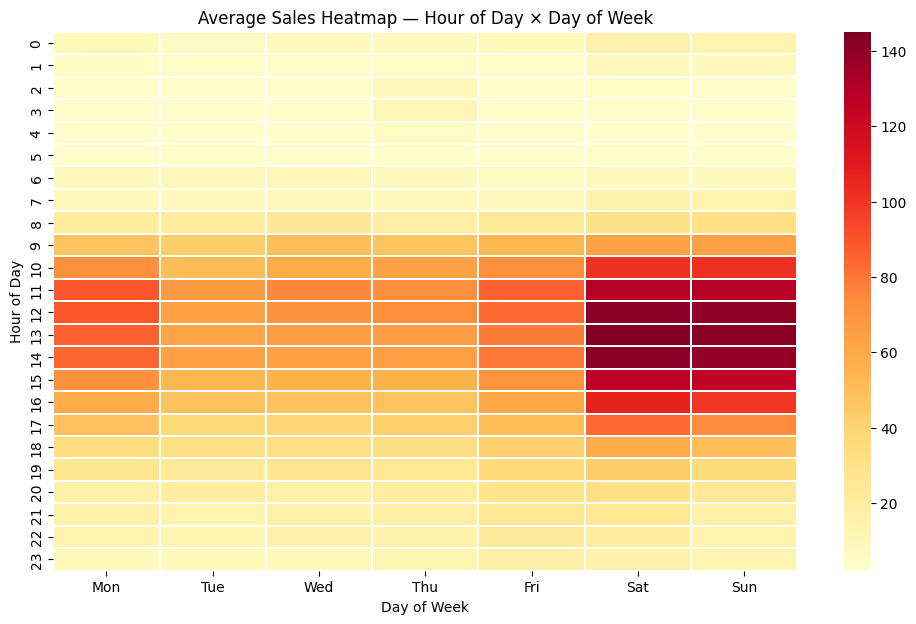

In [20]:
df['hour']       = df['timestamp'].dt.hour
df['day_of_week']= df['timestamp'].dt.dayofweek  # 0=Mon, 6=Sun
df['month']      = df['timestamp'].dt.month
df['date']       = df['timestamp'].dt.date
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

pivot = df.pivot_table(
    values='sales',
    index='hour',
    columns='day_of_week',
    aggfunc='mean'
)
pivot.columns = day_labels

plt.figure(figsize=(12, 7))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, annot=False)
plt.title('Average Sales Heatmap — Hour of Day × Day of Week')
plt.ylabel('Hour of Day')
plt.xlabel('Day of Week')
plt.show()

In [21]:
for lag in [1, 2, 4, 8, 96, 192, 672]:
    df[f'sales_lag_{lag}']       = df['sales'].shift(lag)
    df[f'redemptions_lag_{lag}'] = df['redemptions'].shift(lag)

In [22]:
for window in [4, 8, 96]:
    df[f'sales_rollmean_{window}']  = df['sales'].shift(1).rolling(window).mean()
    df[f'sales_rollstd_{window}']   = df['sales'].shift(1).rolling(window).std()
    df[f'redeem_rollmean_{window}'] = df['redemptions'].shift(1).rolling(window).mean()


In [23]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin']= np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']= np.cos(2 * np.pi * df['month'] / 12)
df['is_peak_hour'] = df['hour'].isin(range(10, 18)).astype(int)
df['quarter']      = df['timestamp'].dt.quarter

In [24]:
df = df.dropna().reset_index(drop=True)

In [25]:
feature_cols = [col for col in df.columns if col not in [
    'timestamp', 'sales', 'redemptions', 'date'
]]

In [27]:
split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]


X_train = train[feature_cols]
y_train_sales = train['sales']
y_train_redeem = train['redemptions']

X_test  = test[feature_cols]
y_test_sales  = test['sales']
y_test_redeem = test['redemptions']
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [29]:


def evaluate(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mask = y_true > 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    print(f"  {model_name}")
    print(f"  MAE  : {mae:.3f}")
    print(f"  RMSE : {rmse:.3f}")
    print(f"  MAPE : {mape:.2f}%")
    print()
    return {'model': model_name, 'MAE': round(mae,3),
            'RMSE': round(rmse,3), 'MAPE': round(mape,2)}

In [30]:
results = []

In [31]:
print("Dataset shape :", df.shape)
print("Feature count :", len(feature_cols))
print("Train/Test split:", len(train), "/", len(test))

Dataset shape : (260866, 39)
Feature count : 35
Train/Test split: 208692 / 52174


In [32]:
results = []  # reset

# 1. Naive
naive_pred = y_test_sales.shift(1).dropna()
naive_true = y_test_sales.iloc[1:].reset_index(drop=True)
naive_pred = naive_pred.reset_index(drop=True)
naive_results = evaluate(naive_true, naive_pred, "Naïve Forecast (Sales)")
results.append(naive_results)

# 2. Moving Average
ma_pred = y_test_sales.shift(1).rolling(window=4).mean().dropna()
ma_true = y_test_sales.iloc[len(y_test_sales) - len(ma_pred):].reset_index(drop=True)
ma_pred = ma_pred.reset_index(drop=True)
ma_results = evaluate(ma_true, ma_pred, "Moving Average Forecast (Sales)")
results.append(ma_results)

# 3. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_sales)
lr_pred = lr_model.predict(X_test_scaled)
lr_pred = np.clip(lr_pred, 0, None)
lr_results = evaluate(y_test_sales, lr_pred, "Linear Regression (Sales)")
results.append(lr_results)

  Naïve Forecast (Sales)
  MAE  : 21.450
  RMSE : 86.374
  MAPE : 128.17%

  Moving Average Forecast (Sales)
  MAE  : 19.521
  RMSE : 69.836
  MAPE : 115.89%

  Linear Regression (Sales)
  MAE  : 18.049
  RMSE : 63.311
  MAPE : 136.31%


📊 Baseline Summary
                          model    MAE   RMSE   MAPE
         Naïve Forecast (Sales) 21.450 86.374 128.17
Moving Average Forecast (Sales) 19.521 69.836 115.89
      Linear Regression (Sales) 18.049 63.311 136.31


In [33]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train_sales)
rf_pred = np.clip(rf_model.predict(X_test), 0, None)

rf_results = evaluate(y_test_sales, rf_pred, "Random Forest (Sales)")

  Random Forest (Sales)
  MAE  : 17.347
  RMSE : 62.952
  MAPE : 120.19%



In [35]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train_sales)
gb_pred = np.clip(gb_model.predict(X_test), 0, None)

gb_results = evaluate(y_test_sales, gb_pred, "Gradient Boosting (Sales)")
results.append(gb_results)

  Gradient Boosting (Sales)
  MAE  : 17.118
  RMSE : 63.005
  MAPE : 116.32%



In [36]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train_sales,
    eval_set=[(X_test, y_test_sales)],
    verbose=False
)
xgb_pred = np.clip(xgb_model.predict(X_test), 0, None)

xgb_results = evaluate(y_test_sales, xgb_pred, "XGBoost (Sales)")
results.append(xgb_results)

  XGBoost (Sales)
  MAE  : 17.490
  RMSE : 63.706
  MAPE : 119.13%



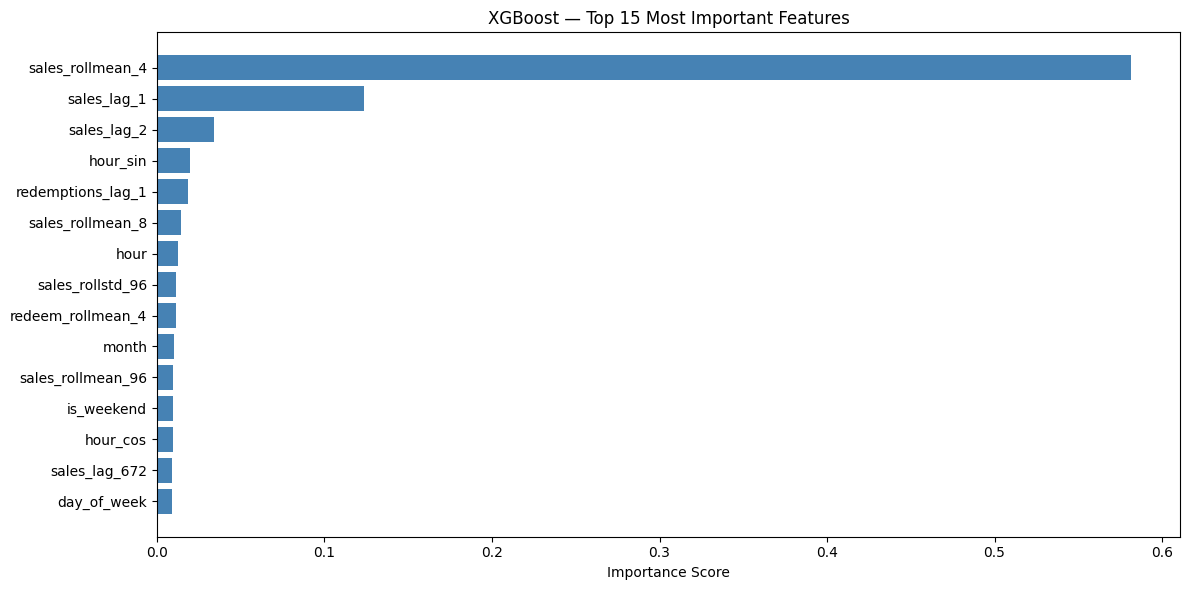

In [38]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.barh(importance_df['feature'][::-1],
         importance_df['importance'][::-1],
         color='steelblue')
plt.title('XGBoost — Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

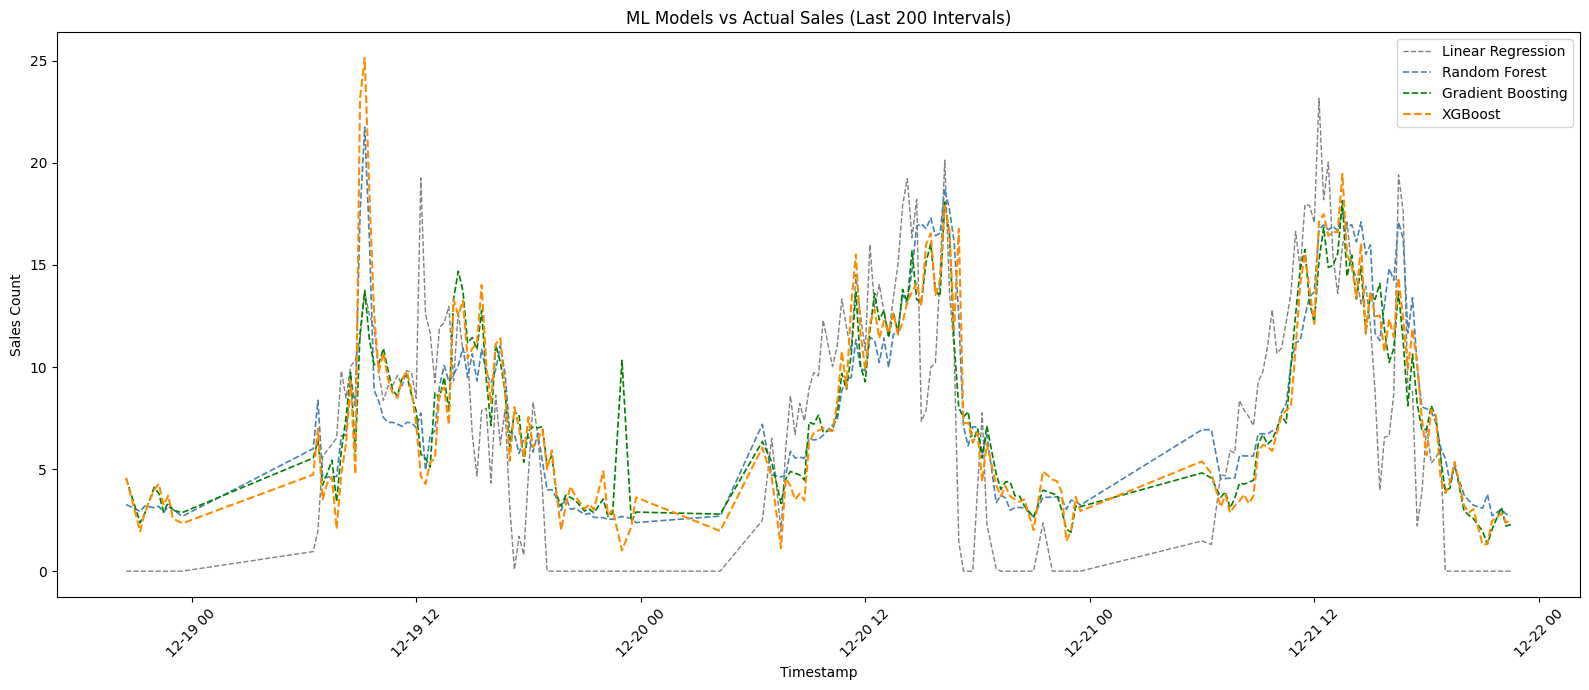

In [39]:
n = 200
plot_index = test['timestamp'].iloc[-n:]
actuals    = y_test_sales.iloc[-n:].values

plt.figure(figsize=(16, 7))
plt.plot(plot_index, lr_pred[-n:],
         label='Linear Regression', color='gray',
         linewidth=1, linestyle='--')
plt.plot(plot_index, rf_pred[-n:],
         label='Random Forest', color='steelblue',
         linewidth=1.2, linestyle='--')
plt.plot(plot_index, gb_pred[-n:],
         label='Gradient Boosting', color='green',
         linewidth=1.2, linestyle='--')
plt.plot(plot_index, xgb_pred[-n:],
         label='XGBoost', color='darkorange',
         linewidth=1.5, linestyle='--')

plt.title('ML Models vs Actual Sales (Last 200 Intervals)')
plt.xlabel('Timestamp')
plt.ylabel('Sales Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
print("\n All Models — Sales Forecast Comparison")
print("="*55)
comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

# Highlight best model
best = comparison_df.loc[comparison_df['MAE'].idxmin()]
print(f"\n Best model so far: {best['model']}  (MAE: {best['MAE']})")


📊 All Models — Sales Forecast Comparison
                          model    MAE   RMSE   MAPE
         Naïve Forecast (Sales) 21.450 86.374 128.17
Moving Average Forecast (Sales) 19.521 69.836 115.89
      Linear Regression (Sales) 18.049 63.311 136.31
      Gradient Boosting (Sales) 17.118 63.005 116.32
                XGBoost (Sales) 17.490 63.706 119.13

🏆 Best model so far: Gradient Boosting (Sales)  (MAE: 17.118)


In [41]:
results

[{'model': 'Naïve Forecast (Sales)',
  'MAE': 21.45,
  'RMSE': np.float64(86.374),
  'MAPE': np.float64(128.17)},
 {'model': 'Moving Average Forecast (Sales)',
  'MAE': 19.521,
  'RMSE': np.float64(69.836),
  'MAPE': np.float64(115.89)},
 {'model': 'Linear Regression (Sales)',
  'MAE': 18.049,
  'RMSE': np.float64(63.311),
  'MAPE': np.float64(136.31)},
 {'model': 'Gradient Boosting (Sales)',
  'MAE': 17.118,
  'RMSE': np.float64(63.005),
  'MAPE': np.float64(116.32)},
 {'model': 'XGBoost (Sales)',
  'MAE': 17.49,
  'RMSE': np.float64(63.706),
  'MAPE': np.float64(119.13)}]


📈 MAE by Forecast Horizon
Model    Linear Reg  Random Forest  XGBoost
Horizon                                    
120 min      30.767         30.051   29.423
15 min       18.717         17.836   17.845
30 min       19.718         18.728   18.576
60 min       22.729         21.697   21.227


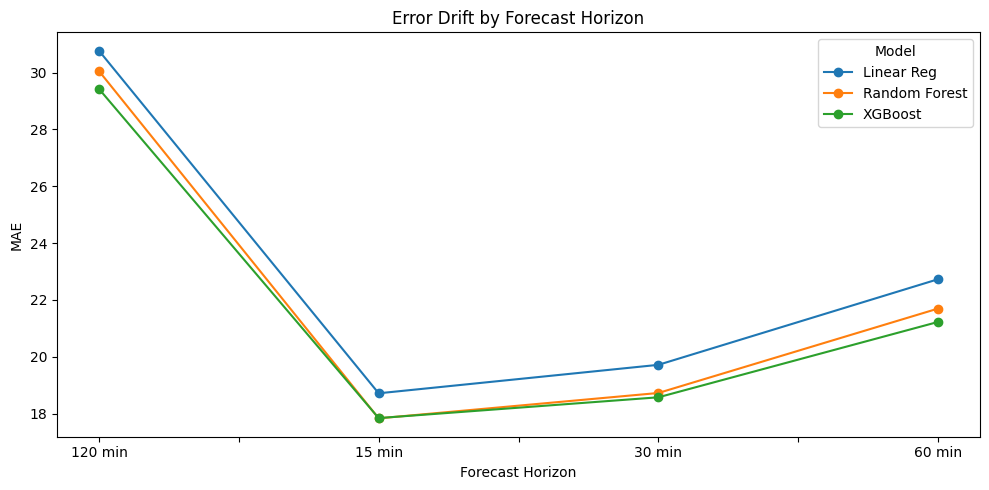

In [42]:
horizons = [1, 2, 4, 8]
horizon_comparison = []

for model_name, preds in [('Linear Reg', lr_pred),
                           ('Random Forest', rf_pred),
                           ('XGBoost', xgb_pred)]:
    for h in horizons:
        y_true_h = y_test_sales.iloc[h:].values
        y_pred_h = preds[:-h]
        mae_h = mean_absolute_error(y_true_h, y_pred_h)
        horizon_comparison.append({
            'Model': model_name,
            'Horizon': f'{h*15} min',
            'MAE': round(mae_h, 3)
        })

hc_df = pd.DataFrame(horizon_comparison)
pivot_h = hc_df.pivot(index='Horizon', columns='Model', values='MAE')

print("\n MAE by Forecast Horizon")
print(pivot_h.to_string())

pivot_h.plot(marker='o', figsize=(10, 5))
plt.title('Error Drift by Forecast Horizon')
plt.ylabel('MAE')
plt.xlabel('Forecast Horizon')
plt.tight_layout()
plt.show()

In [ ]:
from prophet import Prophet
prophet_train = train[['timestamp', 'sales']].rename(
    columns={'timestamp': 'ds', 'sales': 'y'}
)
prophet_test = test[['timestamp', 'sales']].rename(
    columns={'timestamp': 'ds', 'sales': 'y'}
)
prophet_model = Prophet(
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    interval_width=0.95
)

prophet_model.fit(prophet_train)
future = prophet_model.make_future_dataframe(
    periods=len(prophet_test),
    freq='15min',
    include_history=False
)

forecast = prophet_model.predict(future)

prophet_pred = np.clip(forecast['yhat'].values, 0, None)
prophet_lower = np.clip(forecast['yhat_lower'].values, 0, None)
prophet_upper = forecast['yhat_upper'].values

prophet_results = evaluate(y_test_sales, prophet_pred, "Prophet (Sales)")
results.append(prophet_results)

In [ ]:
results

In [49]:
import joblib
from google.colab import files

joblib.dump(gb_model,      'gb_model.pkl')
joblib.dump(rf_model,      'rf_model.pkl')
joblib.dump(xgb_model,     'xgb_model.pkl')
joblib.dump(scaler,        'scaler.pkl')
joblib.dump(feature_cols,  'feature_cols.pkl')

df.to_csv('ferry_data.csv', index=False)

for f in ['gb_model.pkl', 'rf_model.pkl', 'xgb_model.pkl',
          'scaler.pkl', 'feature_cols.pkl', 'ferry_data.csv']:
    files.download(f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded ✅


In [50]:
print("Columns in df:", df.columns.tolist())
print("Date range:", df['timestamp'].min(), "→", df['timestamp'].max())
print("Feature count:", len(feature_cols))
print("Sample feature names:", feature_cols[:5])

Columns in df: ['timestamp', 'redemptions', 'sales', 'hour', 'day_of_week', 'month', 'date', 'is_weekend', 'sales_lag_1', 'redemptions_lag_1', 'sales_lag_2', 'redemptions_lag_2', 'sales_lag_4', 'redemptions_lag_4', 'sales_lag_8', 'redemptions_lag_8', 'sales_lag_96', 'redemptions_lag_96', 'sales_lag_192', 'redemptions_lag_192', 'sales_lag_672', 'redemptions_lag_672', 'sales_rollmean_4', 'sales_rollstd_4', 'redeem_rollmean_4', 'sales_rollmean_8', 'sales_rollstd_8', 'redeem_rollmean_8', 'sales_rollmean_96', 'sales_rollstd_96', 'redeem_rollmean_96', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_peak_hour', 'quarter']
Date range: 2015-05-16 09:00:00 → 2025-12-21 22:30:00
Feature count: 35
Sample feature names: ['hour', 'day_of_week', 'month', 'is_weekend', 'sales_lag_1']
